In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split,cross_validate
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier

In [21]:
pd.set_option('display.max_columns',None)
pd.set_option('display.float_format',lambda x:f"{x: .3f}")
sns.set_theme(style="darkgrid")
plt.rcParams.update({
    'axes.titlesize':10,
    'axes.labelsize':9,
    'xtick.labelsize':8,
    'ytick.labelsize':8,
})

RANDOM_STATE=42
CSV_PATH="../data/creditcard.csv"
TARGET_COLUMN="Class"

In [22]:
df=pd.read_csv(CSV_PATH)

In [23]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [24]:
df.shape

(284807, 31)

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827
1     0.173
Name: proportion, dtype: float64


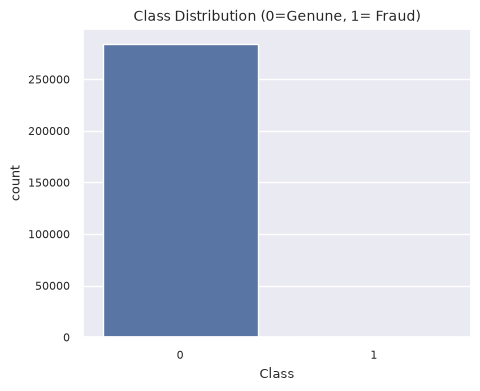

In [26]:
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

fig, ax = plt.subplots(figsize=(5,4))
sns.countplot(x='Class',data=df,ax=ax)
ax.set_title('Class Distribution (0=Genune, 1= Fraud)')
plt.show()

In [28]:
print("Duplicate rows:",df.duplicated().sum())

df.drop_duplicates(inplace=True)
print("Shape after dropping duplicates:",df.shape)


df[['Time','Amount']].describe()

Duplicate rows: 0
Shape after dropping duplicates: (283726, 31)


,Time,Amount
count,283726.000,283726.000
mean,94811.078,88.473
std,47481.048,250.399
min,0.000,0.000
25%,54204.750,5.600
50%,84692.500,22.000
75%,139298.000,77.510
max,172792.000,25691.160


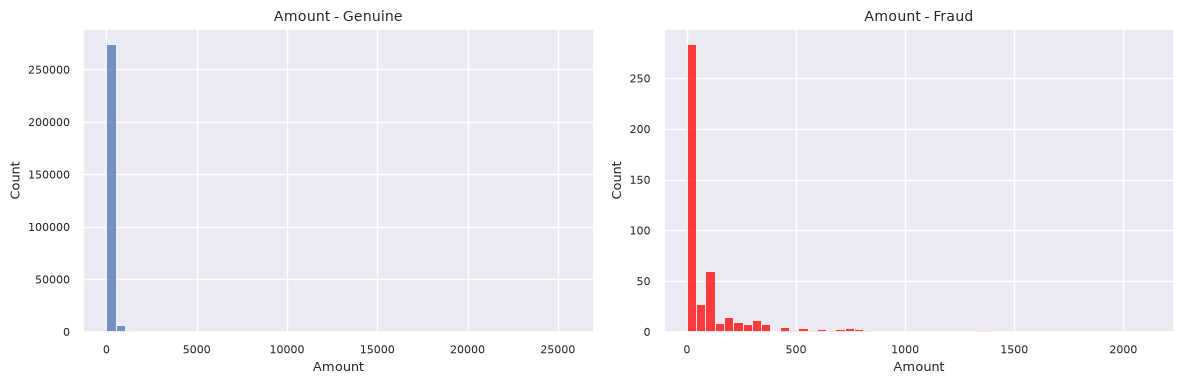

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df[df['Class']==0]['Amount'], bins=50, ax=axes[0])
axes[0].set_title('Amount - Genuine')
sns.histplot(df[df['Class']==1]['Amount'], bins=50, ax=axes[1], color='red')
axes[1].set_title('Amount - Fraud')
plt.tight_layout()
plt.show()